In [2]:
import sys
import os
# Add the project root to the Python path
project_root = '/home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique'
if project_root not in sys.path:
    sys.path.append(project_root)

import functools
import itertools
import operator
from typing import Any
import torch
from torch_geometric.data import Dataset, download_url
from torch.utils.data import random_split
import numpy as np
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt
import torch
from bcos.modules import BcosLinear, BcosSequential
from sklearn.model_selection import train_test_split
from torch.nn import BCEWithLogitsLoss
from torch_geometric.datasets import BA2MotifDataset
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader
from torch_geometric.nn import MessagePassing
from torch_geometric.nn.aggr import SumAggregation
from torch_geometric.utils import add_self_loops, degree
from torchmetrics import AUROC
from torchmetrics.classification import BinaryAccuracy
from tqdm import tqdm
import networkx as nx
import matplotlib.pyplot as plt
import torch.nn.functional as F
from bcosgnn.explain import explain

In [3]:
import sys
sys.path.append("bcosgnn-bcos_gnn_shaique/bcosgnn/")

In [4]:
from bcosgnn.explain import explain

## BCos readout

In [5]:
class Readout(torch.nn.Module):
    def __init__(
        self,
        in_channels,
        hidden_channels=None,
        out_channels=1,
        b=2,
        max_out=1,
        agg: str = "sum",
    ):
        super().__init__()
        if hidden_channels is None:
            self.readout = BcosLinear(in_channels, out_channels, b=b, max_out=max_out)
        else:
            hidden_channels = (
                [hidden_channels]
                if isinstance(hidden_channels, int)
                else hidden_channels
            )
            channels = [in_channels] + hidden_channels + [out_channels]
            self.readout = BcosSequential(
                *[
                    BcosLinear(d_in, d_out, b=b, max_out=max_out)
                    for d_in, d_out in zip(channels[:-1], channels[1:])
                ]
            )
        match agg:
            case "sum":
                self.agg = SumAggregation()
            case _:
                raise ValueError(f"Aggregation '{agg}' not supported.")

    def forward(self, x, batch):
        raise NotImplementedError


class AggThenReadout(Readout):
    def forward(self, x, batch):
        z = self.agg(x, batch)
        out = self.readout(z)
        return out


class ReadoutThenAgg(Readout):
    def forward(self, x, batch):
        z = self.readout(x)
        out = self.agg(z, batch)
        return out

## BCos GCN conv layer

In [6]:
class BcosGCNConv(MessagePassing):
    def __init__(
        self,
        channels: list[int],
        b=2,
        max_out=1,
        *args,
        **kwargs,
    ):
        super().__init__(*args, aggr="add", **kwargs)  # "Add" aggregation (Step 5).
        self.transform = BcosSequential(
            *[
                BcosLinear(din, dout, b=b, max_out=max_out)
                for din, dout in zip(channels[:-1], channels[1:])
            ]
        )

    def forward(self, x, edge_index):
        # Step 1: Add self-loops to the adjacency matrix.
        edge_index, _ = add_self_loops(edge_index, num_nodes=x.size(0))

        # Step 2: Linearly transform node feature matrix.
        x = self.transform(x)

        # Step 3: Compute normalization.
        row, col = edge_index
        deg = degree(col, x.size(0), dtype=x.dtype)
        deg_inv_sqrt = deg.pow(-0.5)
        deg_inv_sqrt[deg_inv_sqrt == float("inf")] = 0
        norm = deg_inv_sqrt[row] * deg_inv_sqrt[col]

        # Step 4-5: Start propagating messages.
        out = self.propagate(edge_index, x=x, norm=norm)

        return out

    def message(self, x_j, norm):
        # x_j has shape [E, out_channels]

        # Step 4: Normalize node features.
        return norm.view(-1, 1) * x_j

## Bcos GNN


In [7]:
class BCosGNN(torch.nn.Module):
    def __init__(
        self,
        node_size: int,
        hidden_channels: int | list[int],
        conv_layer: type[MessagePassing],
        num_convs: int,
        readout: Readout,
        b: float = 2,
        max_out: int = 1,
        conv_kwargs: dict[str, Any] | None = None,
    ):
        super().__init__()
        if isinstance(hidden_channels, int):
            hidden_channels = [hidden_channels]
        conv_kwargs = conv_kwargs or {}
        self.lin_node = BcosLinear(
            node_size,
            hidden_channels[0],
        )
        self.convs = torch.nn.ModuleList(
            [
                conv_layer(
                    channels=hidden_channels,
                    b=b,
                    max_out=max_out,
                    **conv_kwargs,
                )
                for _ in range(num_convs)
            ]
        )
        self.readout = readout

    def forward(self, x, edge_index, batch):
        x = self.lin_node(x)
        for conv in self.convs:
            x = conv(x, edge_index)
        return self.readout(x, batch)

## Dataset creation (custom Ba2Motifs)

In [8]:
import torch
import os
from torch.utils.data import random_split
from torch_geometric.loader import DataLoader


raw_data_path = os.path.join(
    os.path.dirname(os.getcwd()), 
    'data',
    'Custom_BA2Motif', 
    'custom_ba2motif_dataset.pt'
)
print(f"Loading data directly from: {raw_data_path}")



dataset_list = torch.load(raw_data_path, weights_only=False)
print(f"Successfully loaded {len(dataset_list)} graphs.")

for i, data in enumerate(dataset_list):
    data.y = torch.tensor([0]) if i < 500 else torch.tensor([1])
    data.x = torch.ones((data.num_nodes, 1))

first_graph = dataset_list[0]
num_features = first_graph.num_features
all_labels = torch.cat([d.y for d in dataset_list])
num_classes = len(all_labels.unique())

print(f'Number of graphs: {len(dataset_list)}')
print(f'Number of features: {num_features}')
print(f'Number of classes: {num_classes}')


train_split_idx, test_split_idx = train_test_split(
    np.arange(len(dataset_list)), test_size=0.2, train_size=0.8, random_state=42
)

train_dataset = [dataset_list[i] for i in train_split_idx]
test_dataset = [dataset_list[i] for i in test_split_idx]

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Loading data directly from: /home/moso00002/Desktop/gnn/bcosgnn-bcos_gnn_shaique/shaique_updates/data/Custom_BA2Motif/custom_ba2motif_dataset.pt
Successfully loaded 1000 graphs.
Number of graphs: 1000
Number of features: 1
Number of classes: 2
Training set size: 800
Test set size: 200


In [9]:
def get_one_hot_degree_clamped(data, max_degree=10):
    row, col = data.edge_index
    deg = degree(col, data.num_nodes, dtype=torch.long)
    deg = deg.clamp(max=max_degree)
    one_hot_deg = torch.nn.functional.one_hot(deg, num_classes=max_degree + 1).to(
        torch.float
    )
    data.x = one_hot_deg.float()
    return data

  Graph Index 0: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 1: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 2: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 3: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 4: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 5: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 6: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 7: Node Mask = [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 1. 1. 1. 1. 1.]
  Graph Index 8: Node Ma

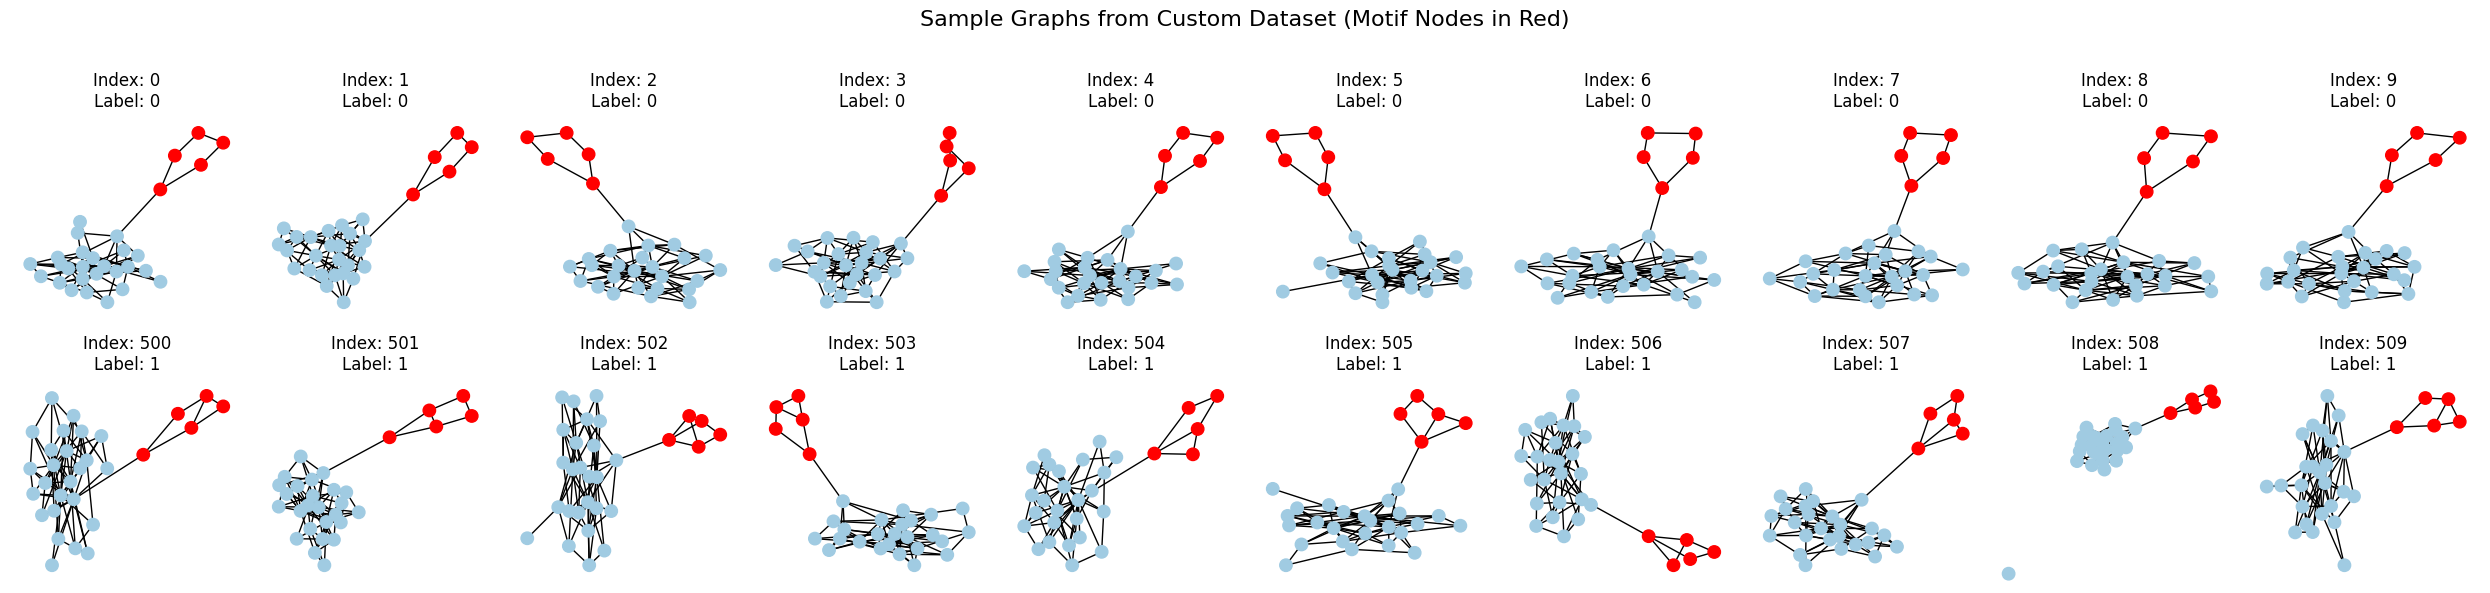

In [10]:
import networkx as nx
import matplotlib.pyplot as plt


class_0_samples = []
class_1_samples = []

for i, data in enumerate(dataset_list):
    if data.y.item() == 0 and len(class_0_samples) < 10:
        class_0_samples.append((i, data))
    elif data.y.item() == 1 and len(class_1_samples) < 10:
        class_1_samples.append((i, data))
    
    if len(class_0_samples) == 10 and len(class_1_samples) == 10:
        break

fig, axes = plt.subplots(2, 10, figsize=(25, 6))
fig.suptitle("Sample Graphs from Custom Dataset (Motif Nodes in Red)", fontsize=16)

#  Class 0 (Cycle Motif) 
for i, (original_index, data) in enumerate(class_0_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[0, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 0")

#  Class 1 (House Motif) 
for i, (original_index, data) in enumerate(class_1_samples):
    print(f"  Graph Index {original_index}: Node Mask = {data.node_mask.numpy().ravel()}")
    
    g = nx.Graph()
    g.add_nodes_from(range(data.num_nodes))
    g.add_edges_from(data.edge_index.t().tolist())
    
    node_colors = ['red' if mask == 1 else '#A0CBE2' for mask in data.node_mask]
    
    ax = axes[1, i]
    pos = nx.spring_layout(g, seed=42)
    nx.draw(g, pos, ax=ax, with_labels=False, node_color=node_colors, node_size=80)
    ax.set_title(f"Index: {original_index}\nLabel: 1")

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

## Train and test logic

In [11]:
def train_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    optim.zero_grad()
    loss.backward()
    optim.step()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


@torch.inference_mode()
def test_step(model, batch, criterion, optim, metrics=None):
    metrics = metrics or {}
    step_info = {"batch_size": batch.y.size(0)}
    pred = model(batch.x, batch.edge_index, batch.batch)
    step_info["pred"] = pred
    loss = criterion(pred.flatten(), batch.y.float())
    step_info["loss"] = loss.item()
    for name, metric in metrics.items():
        step_info[name] = metric(pred, batch.y)
    return step_info


def run_epoch(
    step_fn,
    model,
    data_loader,
    criterion,
    optim,
    step_metrics=None,
    epoch_metrics=None,
):
    epoch_metrics = epoch_metrics or {}
    for metric in epoch_metrics.values():
        metric.reset()
    epoch_info = {"steps": []}
    for step_index, batch in enumerate(data_loader):
        step_info = step_fn(model, batch, criterion, optim, step_metrics) | {
            "step_index": step_index
        }
        epoch_info["steps"].append(step_info)
        for metric in epoch_metrics.values():
            metric.update(step_info["pred"].squeeze(), batch.y)
    for name, metric in epoch_metrics.items():
        epoch_info[name] = metric.compute()
    return epoch_info


def train_and_test_model(
    model: BCosGNN,
    train_data: list,
    test_data: list,
    transform,
    num_train_epochs: int,
    lr: float,
    batch_size: int,
):
    if transform:
        train_data = [transform(d.clone()) for d in train_data]
        test_data = [transform(d.clone()) for d in test_data]

    optim = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = BCEWithLogitsLoss()
    
    train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)
    
    train_epochs = [
        run_epoch(
            train_step,
            model,
            train_loader,
            criterion,
            optim,
            step_metrics=None,
            epoch_metrics={"accuracy": BinaryAccuracy()},
        )
        | {"epoch_index": epoch_index}
        for epoch_index in tqdm(
            range(num_train_epochs), f"Training {model.__class__.__name__}"
        )
    ]
    test_epoch = run_epoch(
        test_step,
        model,
        test_loader,
        criterion,
        optim,
        step_metrics=None,
        epoch_metrics={"accuracy": BinaryAccuracy()},
    )
    return train_epochs, test_epoch

In [12]:
def get_many(d, *keys):
    return {d[key] for key in keys}


def to_polars(train_epochs, test_epoch, **markers):
    df_epoch = pl.DataFrame(
        {
            "epoch_index": [epoch["epoch_index"] for epoch in train_epochs] + [0],
            "accuracy": [epoch["accuracy"].item() for epoch in train_epochs]
            + [test_epoch["accuracy"]],
            "split": ["train"] * len(train_epochs) + ["test"],
        }
    )
    if len(markers) > 0:
        df_epoch = df_epoch.with_columns(
            *[
                pl.lit(marker_value).alias(marker_key)
                for marker_key, marker_value in markers.items()
            ]
        )
    return df_epoch, None

In [13]:
train_hyperparams = {
    "num_train_epochs": 40,
    "batch_size": 64,
    "lr": 3e-4,
}

interventions = {
    "conv_capacity": {
        "64": dict(hidden_channels=64),
        "64,64": dict(hidden_channels=[64, 64]),
    },
    "readout_order": {
        "agg_then_readout": dict(readout_cls=AggThenReadout),
        "readout_then_agg": dict(readout_cls=ReadoutThenAgg),
    },
    "readout_capacity": {
        "64": dict(readout_hidden_channels=64),
        "64,64": dict(readout_hidden_channels=[64, 64]),
    },
    "feature_transform": {
        "none": dict(transform=None, node_size=1), 
        "degree": dict(
            transform=functools.partial(get_one_hot_degree_clamped, max_degree=4),
            node_size=5,
        ),
    },
}

# Generate all combinations
keys = list(interventions.keys())
values_product = itertools.product(*(interventions[k].items() for k in keys))

default_model_hyperparams = dict(
    transform=None,
    conv_layer=BcosGCNConv,
    num_convs=3,
    readout_cls=AggThenReadout,
    readout_in_channels=64,
    readout_hidden_channels=64,
    b=2,
    max_out=1,
)
dfs = []
for combo in values_product:
    intrv = {k: name for k, (name, _) in zip(keys, combo)}
    hyperparam_changes = [params for _, params in combo]
    hyperparams = functools.reduce(
        operator.or_, hyperparam_changes, default_model_hyperparams
    )

    print("intervention:", intrv)
    print("hyperparams:", hyperparams)
    
    model = BCosGNN(
        node_size=hyperparams["node_size"],
        hidden_channels=hyperparams["hidden_channels"],
        conv_layer=hyperparams["conv_layer"],
        num_convs=hyperparams["num_convs"],
        readout=hyperparams["readout_cls"](
            in_channels=hyperparams["readout_in_channels"],
            hidden_channels=hyperparams["readout_hidden_channels"],
            b=hyperparams["b"],
            max_out=hyperparams["max_out"],
        ),
        b=hyperparams["b"],
        max_out=hyperparams["max_out"],
    )
    
    train_epochs, test_epoch = train_and_test_model(
        model=model,
        train_data=train_dataset, 
        test_data=test_dataset,   
        transform=hyperparams["transform"],
        **train_hyperparams,
    )
    
    df_train, df_test = to_polars(
        train_epochs=train_epochs, test_epoch=test_epoch, **intrv
    )
    dfs.append(df_train)

df = pl.concat(dfs)

intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 1}


Training BCosGNN: 100%|██████████| 40/40 [00:03<00:00, 13.17it/s]


intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x79de68c9d9e0>, max_degree=4), 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': 64, 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 5}


Training BCosGNN: 100%|██████████| 40/40 [00:03<00:00, 12.33it/s]


intervention: {'conv_capacity': '64', 'readout_order': 'agg_then_readout', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.AggThenReadout'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': 64, 'node_size': 1}


...

Training BCosGNN: 100%|██████████| 40/40 [00:04<00:00,  8.31it/s]


intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'none'}
hyperparams: {'transform': None, 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 1}


Training BCosGNN: 100%|██████████| 40/40 [00:05<00:00,  7.89it/s]


intervention: {'conv_capacity': '64,64', 'readout_order': 'readout_then_agg', 'readout_capacity': '64,64', 'feature_transform': 'degree'}
hyperparams: {'transform': functools.partial(<function get_one_hot_degree_clamped at 0x79de68c9d9e0>, max_degree=4), 'conv_layer': <class '__main__.BcosGCNConv'>, 'num_convs': 3, 'readout_cls': <class '__main__.ReadoutThenAgg'>, 'readout_in_channels': 64, 'readout_hidden_channels': [64, 64], 'b': 2, 'max_out': 1, 'hidden_channels': [64, 64], 'node_size': 5}


Training BCosGNN: 100%|██████████| 40/40 [00:05<00:00,  7.55it/s]


In [14]:
df

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
1,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
2,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
3,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
4,0.505,"""train""","""64""","""agg_then_readout""","""64""","""none"""
…,…,…,…,…,…,…
36,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
37,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""
38,1.0,"""train""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


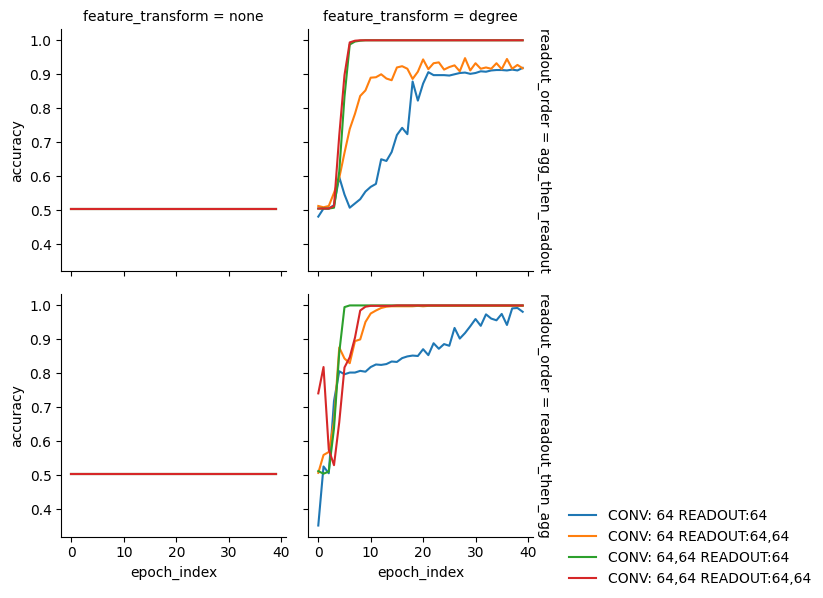

In [15]:
g = sns.FacetGrid(
    df.filter(pl.col("split") == "train").with_columns(
        pl.concat_str(
            pl.lit("CONV: "),
            pl.col("conv_capacity"),
            pl.lit(" READOUT:"),
            pl.col("readout_capacity"),
        ).alias("model_capacity")
    ),
    col="feature_transform",
    
    row="readout_order",
    margin_titles=True,
)
g.map_dataframe(sns.lineplot, x="epoch_index", y="accuracy", hue="model_capacity")
g.add_legend()
sns.move_legend(g, loc="lower right")

In [16]:
df.filter(pl.col("split") == "test", pl.col("feature_transform") == "degree")

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.935,"""test""","""64""","""agg_then_readout""","""64""","""degree"""
0,0.935,"""test""","""64""","""agg_then_readout""","""64,64""","""degree"""
0,0.92,"""test""","""64""","""readout_then_agg""","""64""","""degree"""
0,0.995,"""test""","""64""","""readout_then_agg""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64,64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64""","""degree"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64,64""","""degree"""


In [17]:
df.filter(pl.col("split") == "test")

epoch_index,accuracy,split,conv_capacity,readout_order,readout_capacity,feature_transform
i64,f64,str,str,str,str,str
0,0.48,"""test""","""64""","""agg_then_readout""","""64""","""none"""
0,0.935,"""test""","""64""","""agg_then_readout""","""64""","""degree"""
0,0.48,"""test""","""64""","""agg_then_readout""","""64,64""","""none"""
0,0.935,"""test""","""64""","""agg_then_readout""","""64,64""","""degree"""
0,0.48,"""test""","""64""","""readout_then_agg""","""64""","""none"""
…,…,…,…,…,…,…
0,1.0,"""test""","""64,64""","""agg_then_readout""","""64,64""","""degree"""
0,0.48,"""test""","""64,64""","""readout_then_agg""","""64""","""none"""
0,1.0,"""test""","""64,64""","""readout_then_agg""","""64""","""degree"""


In [ ]:
best_hyperparams = {
    "node_size": 5,
    "hidden_channels": [64 , 64],
    "conv_layer": BcosGCNConv,
    "num_convs": 3,
    "readout": ReadoutThenAgg(
        in_channels=64,
        hidden_channels= [64, 64],
        b=2,
        max_out=1,
    ),
    "b": 2,
    "max_out": 1,
}

In [66]:
best_model = BCosGNN(**best_hyperparams)

transform = functools.partial(get_one_hot_degree_clamped, max_degree=4)

train_epochs, test_epoch = train_and_test_model(

    model=best_model,

    train_data=train_dataset,

    test_data=test_dataset,

    transform=transform,

    **train_hyperparams,

)

print(f"Best model test accuracy: {test_epoch['accuracy']:.4f}")


Training BCosGNN: 100%|██████████| 40/40 [00:05<00:00,  7.20it/s]

Best model test accuracy: 1.0000


In [ ]:
def get_explanation(model, data):

    model.eval()

    with torch.no_grad():

        data = transform(data.clone())
        
        x = model.lin_node(data.x)

        for conv in model.convs:

            x = conv(x, data.edge_index)
        
        node_scores = model.readout.readout(x)
        
        return node_scores.squeeze()

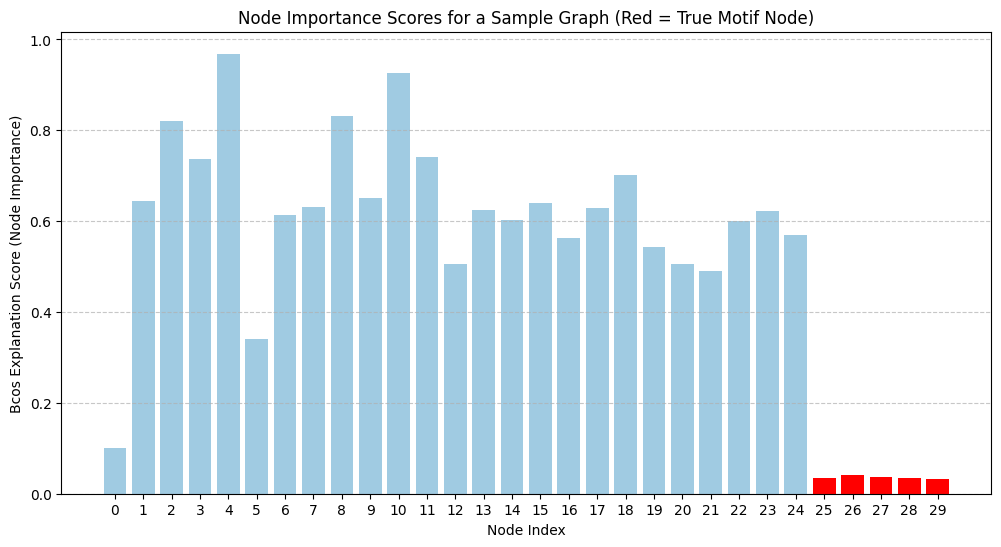

In [26]:
sample_data = test_dataset[10].clone() 

node_importance_scores = get_explanation(best_model, sample_data)

node_importance_scores = node_importance_scores.numpy()

ground_truth_mask = sample_data.node_mask.numpy().ravel()

plt.figure(figsize=(12, 6))

nodes = np.arange(sample_data.num_nodes)

colors = ['red' if mask == 1 else '#A0CBE2' for mask in ground_truth_mask]

plt.bar(nodes, node_importance_scores, color=colors)

plt.xlabel("Node Index")

plt.ylabel("Bcos Explanation Score (Node Importance)")

plt.title("Node Importance Scores for a Sample Graph (Red = True Motif Node)")

plt.xticks(nodes)

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [20]:
def evaluate_explanation_accuracy(model, data):

    explanation_scores = get_explanation(model, data)
    
    ground_truth_nodes = set(torch.where(data.node_mask.squeeze() == 1)[0].numpy())
    
    k = len(ground_truth_nodes)
    
    if k == 0:

        return 1.0 if len(explanation_scores) == 0 else 0.0

    _, top_k_indices = torch.topk(explanation_scores, k)

    predicted_important_nodes = set(top_k_indices.numpy())
    
    intersection = len(ground_truth_nodes.intersection(predicted_important_nodes))
    
    union = len(ground_truth_nodes.union(predicted_important_nodes))
    
    return intersection / union if union > 0 else 0.0


In [21]:
explanation_accuracies = []

for data in tqdm(test_dataset, desc="Evaluating explanations on test set"):

    accuracy = evaluate_explanation_accuracy(best_model, data.clone())

    explanation_accuracies.append(accuracy)

average_accuracy = np.mean(explanation_accuracies)

print(f"Average Explanation Accuracy (Jaccard Score) on Test Set: {average_accuracy:.4f}")

print("\nThis score measures how well the model's top important nodes align with the ground-truth motif nodes across all graphs in the test set.")

Evaluating explanations on test set: 100%|██████████| 200/200 [00:00<00:00, 737.93it/s]

Average Explanation Accuracy (Jaccard Score) on Test Set: 0.0000

This score measures how well the model's top important nodes align with the ground-truth motif nodes across all graphs in the test set.


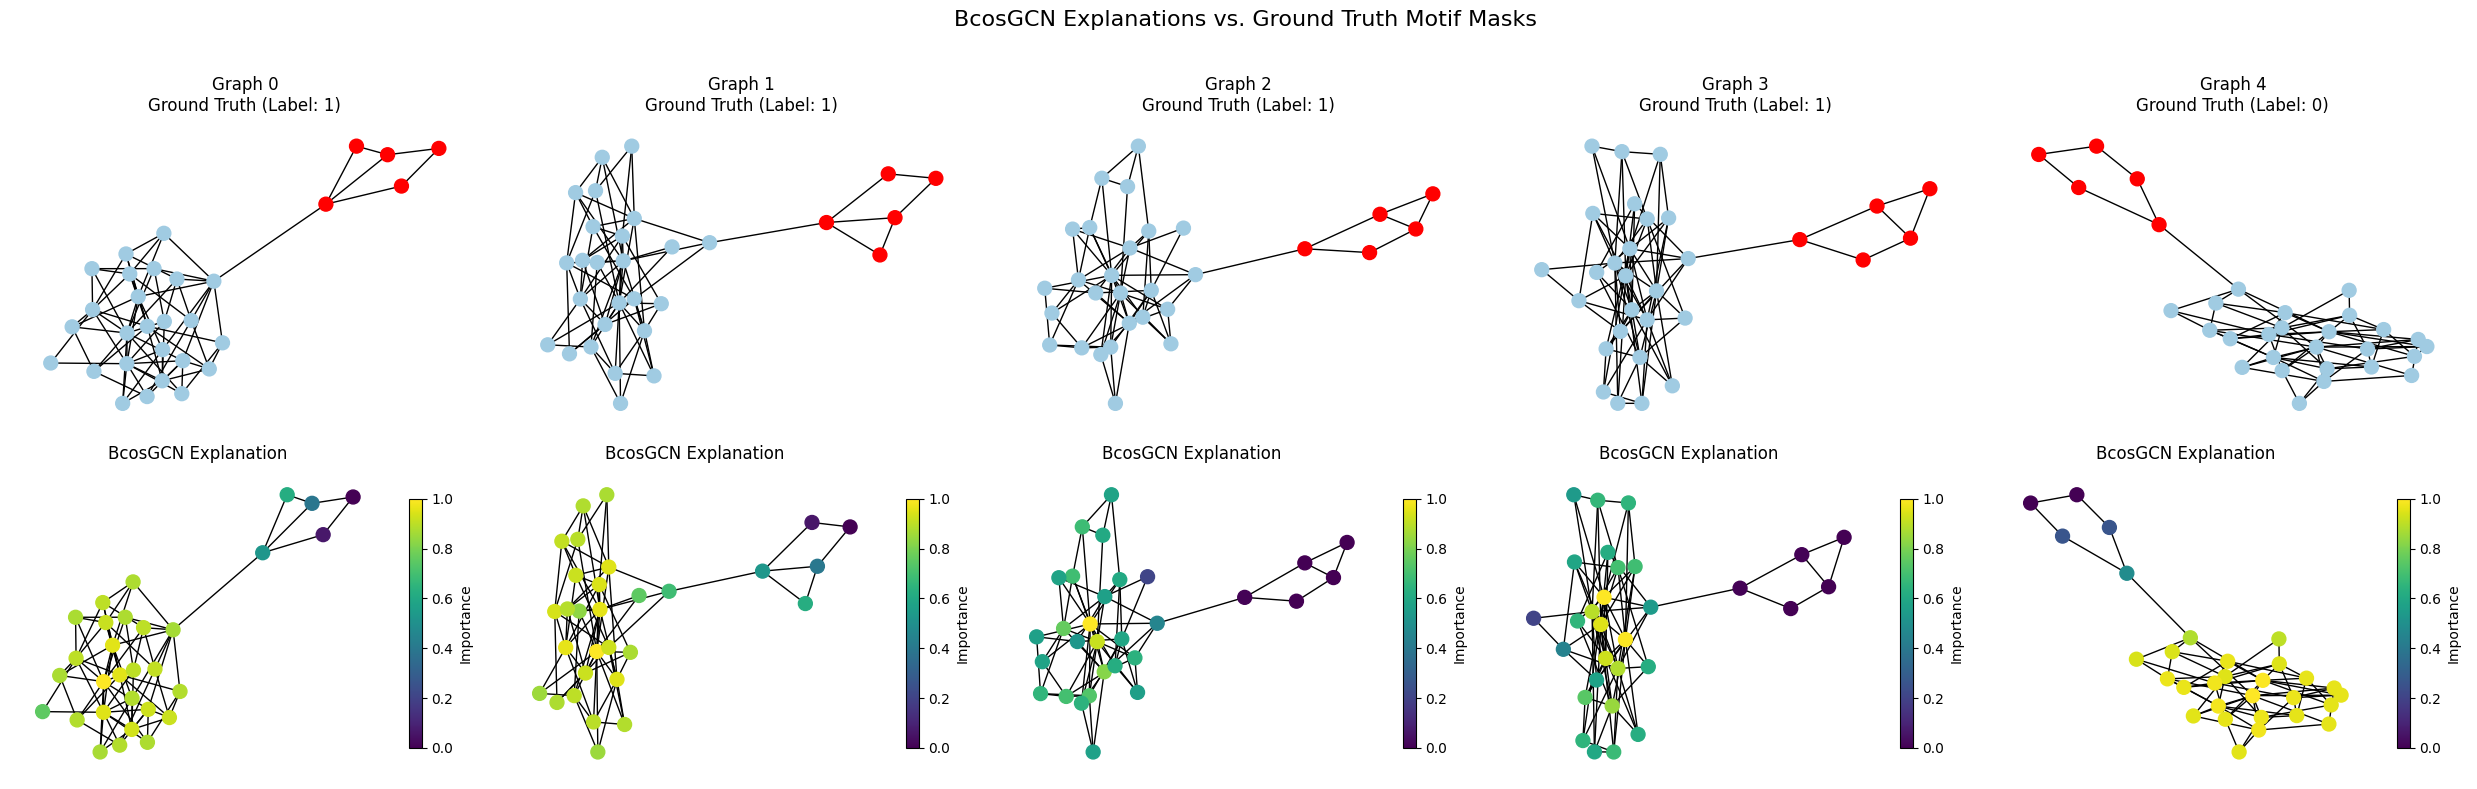

In [22]:
num_samples_to_visualize = 5

fig, axes = plt.subplots(2, num_samples_to_visualize, figsize=(25, 8))

fig.suptitle("BcosGCN Explanations vs. Ground Truth Motif Masks", fontsize=16)

sample_test_data = [d.clone() for d in test_dataset[:num_samples_to_visualize]]

for i, data in enumerate(sample_test_data):

    node_explanations = get_explanation(best_model, data)

    ground_truth_mask = data.node_mask.numpy().ravel()
    
    g = nx.Graph()

    g.add_nodes_from(range(data.num_nodes))

    g.add_edges_from(data.edge_index.t().tolist())

    pos = nx.spring_layout(g, seed=42)

    ax_gt = axes[0, i]

    node_colors_gt = ['red' if mask == 1 else '#A0CBE2' for mask in ground_truth_mask]

    nx.draw(g, pos, ax=ax_gt, with_labels=False, node_color=node_colors_gt, node_size=100)

    ax_gt.set_title(f"Graph {i}\nGround Truth (Label: {data.y.item()})")

    ax_exp = axes[1, i]

    node_colors_exp = node_explanations.numpy()
    
    nodes = nx.draw(g, pos, ax=ax_exp, with_labels=False, node_color=node_colors_exp, cmap=plt.cm.viridis, node_size=100)
    
    cbar = fig.colorbar(nodes, ax=ax_exp, shrink=0.8)

    cbar.set_label('Importance', fontsize=10)
    
    ax_exp.set_title(f"BcosGCN Explanation")

plt.tight_layout(rect=[0, 0, 1, 0.96])

plt.show()

In [71]:
model = best_model
data = test_dataset[50]
data = get_one_hot_degree_clamped(data.clone(), max_degree=4)

node_contributions = explain(
    model,
    data.x,
    data.edge_index,
    torch.zeros(data.x.size(0), device=data.x.device, dtype=torch.long),
).detach()

with torch.no_grad():

    pred = model(data.x, data.edge_index, torch.zeros(data.x.size(0), dtype=torch.long))


In [72]:
pred.sum(), node_contributions.sum()

(tensor(10.5549), tensor(10.5549))

In [73]:
import networkx as nx


def visualize_explanation(graph_data, node_importance):
    g = nx.Graph()
    g.add_nodes_from(range(graph_data.num_nodes))
    g.add_edges_from(graph_data.edge_index.t().tolist())

    plt.figure(figsize=(8, 8))

    node_colors = node_importance.numpy()

    edge_colors = [max(node_colors[u], node_colors[v]) for u, v in g.edges()]

    pos = nx.spring_layout(g, seed=42)

    nodes = nx.draw_networkx_nodes(
        g, pos, node_color=node_colors, cmap=plt.cm.viridis, node_size=500
    )
    edges = nx.draw_networkx_edges(
        g, pos, edge_color=edge_colors, edge_cmap=plt.cm.viridis, width=2
    )
    nx.draw_networkx_labels(g, pos, font_color="white")

    plt.colorbar(nodes, label="Node Importance (Cosine Similarity)")
    plt.title("Explanation for a single graph")
    plt.show()

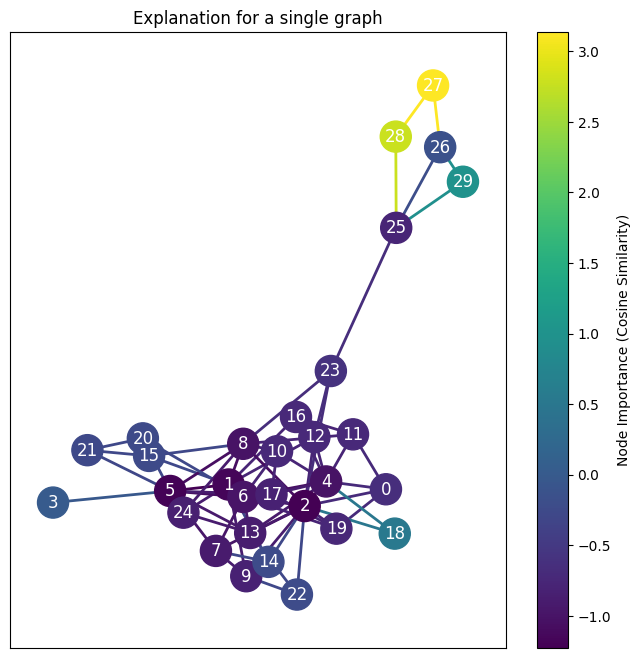

In [74]:
visualize_explanation(data, -(node_contributions.sum(1)))


In [1]:
df.filter(pl.col("split") == "test")

NameError: name 'df' is not defined